# Analyzing the Relationship Between Cardiac Biomarkers and Disease Diagnosis

##  Problem Statement
Cardiovascular diseases (CVDs) remain the among leading causes of death globally. Accounting for approximately 17.9 million deaths each year as per the World Health Organization. Early detection and timely diagnosis are critical to improving patient outcomes, especially in emergency and primary care settings where quick decision-making can be life-saving. Among the many diagnostic tools available, biochemical cardiac markers such as Troponin and CK-MB, alongside vital signs like blood pressure and heart rate, play a pivotal role in identifying cardiac events such as myocardial infarction (heart attack) and related conditions.

However, in resource-limited environments or data-scarce clinical settings, the interpretation of such biomarkers can often be subjective or delayed due to the lack of integrated insights from multiple parameters. While individual markers have established diagnostic value, the interrelationship between these indicators, patient demographics (such as age and gender), and overall diagnostic outcomes remains underexplored from a data-driven perspective—particularly using real-world, open-source datasets.

This exploratory study leverages a publicly available dataset from Kaggle source containing clinical records of 1,319 patients, including variables such as age, gender, heart rate, systolic and diastolic blood pressure, blood sugar levels, CK-MB, and Troponin, along with their diagnostic classification (positive or negative). The dataset was retrieved from: https://www.kaggle.com/api/v1/datasets/download/fatemehmohammadinia/heart-attack-dataset-tarik-a-rashid .The core problem this study addresses is:

To what extent do cardiac biomarkers (e.g., Troponin, CK-MB) and vital physiological indicators correlate with the diagnosis of cardiac conditions, and can exploratory data analysis uncover meaningful patterns or early warning signals across patient demographics?

## Objectives:

1. Understand statistical distributions and variable interactions across healthy and unhealthy cohorts.
2. Identify potential biomarker thresholds or combinations that are highly associated with positive diagnoses.
3. Provide data-driven evidence that can support early triage or risk stratification models in clinical decision-making.

In [2]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings # used to ignore warnings
warnings.filterwarnings('ignore')
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import ExtraTreesClassifier
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import statistics
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, roc_curve, auc
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix

## 1. Load dataset

In [3]:
# Loads dataset from my github account
df = pd.read_csv('/workspaces/EDA_Cardiac_Biomarkers_-_Disease_Diagnosis/Medicaldataset.csv')

## 2.Data Inspection

In [5]:
# Loads the first 5 rows of the dataset
print("Sample Data:\n", df.head())

Sample Data:
    Age  Gender  Heart rate  Systolic blood pressure  Diastolic blood pressure  \
0   64       1          66                      160                        83   
1   21       1          94                       98                        46   
2   55       1          64                      160                        77   
3   64       1          70                      120                        55   
4   55       1          64                      112                        65   

   Blood sugar  CK-MB  Troponin    Result  
0        160.0   1.80     0.012  negative  
1        296.0   6.75     1.060  positive  
2        270.0   1.99     0.003  negative  
3        270.0  13.87     0.122  positive  
4        300.0   1.08     0.003  negative  


In [6]:
# displaying the rows and columns of the dataset
print("Initial Shape:", df.shape)

Initial Shape: (1319, 9)


In [ ]:
# shows the different data types
print("Data Types:\n", df.dtypes)

Data Types:
 Age                           int64
Gender                        int64
Heart rate                    int64
Systolic blood pressure       int64
Diastolic blood pressure      int64
Blood sugar                 float64
CK-MB                       float64
Troponin                    float64
Result                       object
dtype: object


In [5]:
# printing missing values
print("Missing Values:\n", df.isnull().sum())

Missing Values:
 Age                         0
Gender                      0
Heart rate                  0
Systolic blood pressure     0
Diastolic blood pressure    0
Blood sugar                 0
CK-MB                       0
Troponin                    0
Result                      0
dtype: int64


In [ ]:
# printing value counts for males(1) and females(0)
print(df["Gender"].value_counts())

Gender
1    870
0    449
Name: count, dtype: int64


In [9]:
# Detecting outliers
def find_outliers(df):
    anomalies = []
    
    # setting upper and lower limit to 3 standard deviation
    random_data_std = statistics.stdev(df) #3-standard deviation method
    random_data_mean = statistics.mean(df)

    anomaly_cut_off = random_data_std * 3

    lower_limit = random_data_mean - anomaly_cut_off
    upper_limit = random_data_mean + anomaly_cut_off

    # Generate outliers
    for outlier in df:
        if outlier > upper_limit or outlier < lower_limit:
            anomalies.append(outlier)
    return anomalies


In [ ]:
# finding outliers in Troponin beyond 3 standard deviation
df_1 = find_outliers(df['Troponin'])
len(df_1)

26

<Axes: xlabel='Troponin', ylabel='Density'>

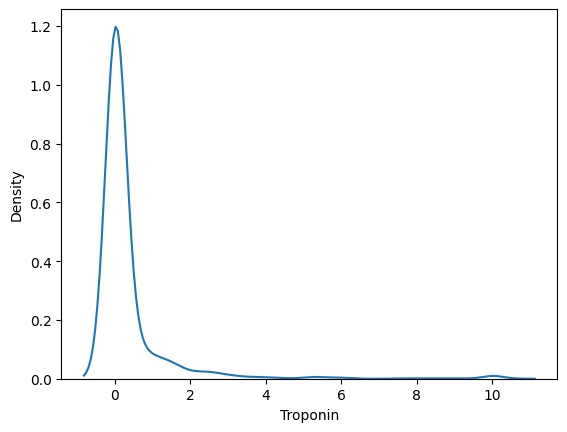

In [8]:
# checking whether the data is skewed
df.Troponin.skew() #value shows that the data is postively skewed
sns.kdeplot(df.Troponin)

3. ## Data preprocessing

In [ ]:
# df = df.drop(['Column'], axis= 1)
# df.info

In [6]:
# reducing ouliers in Troponin
df['Troponin_transformed'] = np.log(df.Troponin)

In [ ]:
# checks if skewness has been reduced and in this case, it has been reduced)
df.Troponin_transformed.skew()

np.float64(0.9744406572078642)

<Axes: xlabel='Troponin_transformed', ylabel='Density'>

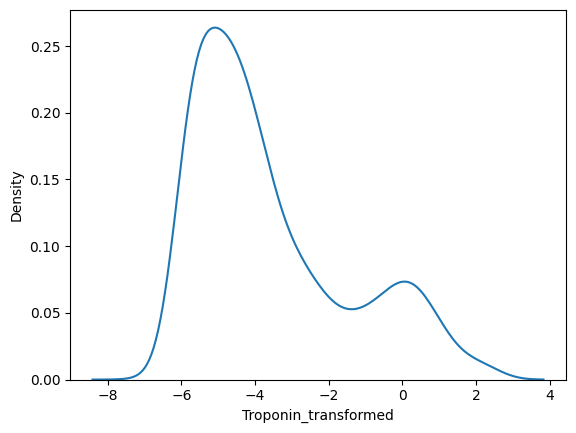

In [ ]:
# checking whether the data is skewed(review this method later)
df.Troponin_transformed.skew() #value shows that the data is postively skewed
sns.kdeplot(df.Troponin_transformed)

In [ ]:
# further reducing ouliers in Troponin(I commented it out coz result was negative)
# df['Troponin_double_transformed'] = np.log(df.Troponin_transformed)

In [ ]:
# checks if skewness has been reduced further and in this case, it has been reduced)
# df.Troponin_double_transformed.skew()

np.float64(-1.2399565916224697)

In [4]:
# Feature importance,checking independent features with strongest relationship to dependent feature
X = df.drop('Result', axis=1)  # All columns except 'Result'
y = df['Result']

# Encode the target variable (convert 'positive'/'negative' to 1/0)
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)               # Target column

# Ensure X contains only non-negative values (required for chi2)
X = X.clip(lower=0)


# Feature selection
features = SelectKBest(score_func=chi2, k=5)  # Select top 5 features
fit = features.fit(X, y)
dfscores = pd.DataFrame(fit.scores_)
dfcolumns = pd.DataFrame(X.columns)
featureScores = pd.concat([dfcolumns, dfscores], axis=1)
featureScores.columns = ['Specs', 'Score']
print(featureScores.sort_values(by='Score', ascending=False))

                      Specs        Score
6                     CK-MB  8778.481659
7                  Troponin   256.102264
0                       Age   247.653485
5               Blood sugar    55.144417
1                    Gender     4.003940
3   Systolic blood pressure     3.067159
2                Heart rate     2.147992
4  Diastolic blood pressure     0.335111


In [5]:
# checking importance of each feature towards the positive or negative results of patients
model = ExtraTreesClassifier()
model.fit(X,y)
print(model.feature_importances_)

[0.11719015 0.01321656 0.07125727 0.07222768 0.07233336 0.08151541
 0.21869236 0.3535672 ]


<function matplotlib.pyplot.show(close=None, block=None)>

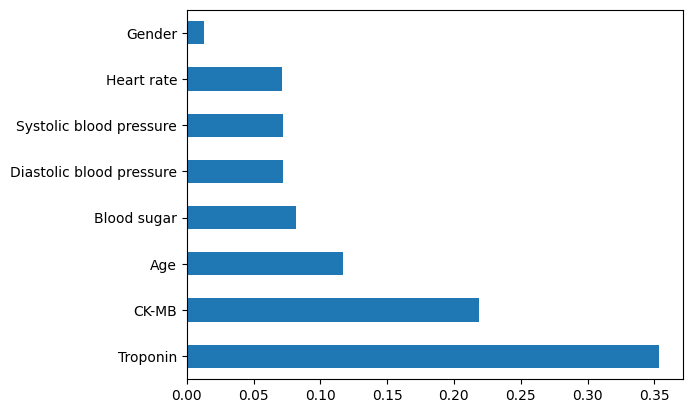

In [6]:
feature_importances = pd.Series(model.feature_importances_, index = X.columns)
feature_importances.nlargest(10).plot(kind= 'barh')
plt.show


In [7]:
# Defining which columns are numeric, which are categorical and the target for data visualization
# Features
numeric_features = [
    'Age', 
    'Heart rate', 
    'Systolic blood pressure', 
    'Diastolic blood pressure',
    'Blood sugar', 
    'CK-MB', 
    'Troponin'
]

categorical_features = ['Gender']



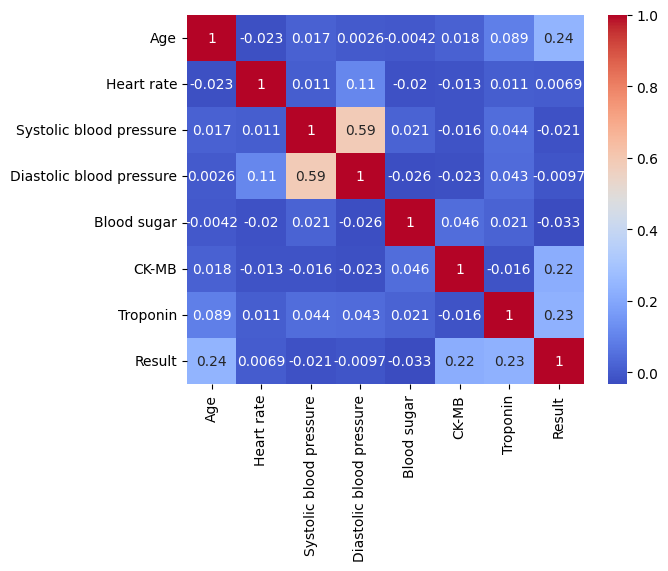

In [7]:
# Defining which columns are numeric, which are categorical and the target for data visualization
# Features
numeric_features = [
    'Age', 
    'Heart rate', 
    'Systolic blood pressure', 
    'Diastolic blood pressure',
    'Blood sugar', 
    'CK-MB', 
    'Troponin'
]

df['Result'] = df['Result'].map({'positive': 1, 'negative': 0})
df = df.dropna(subset=['Result'])
df = df[~df['Result'].isin([float('inf'), float('-inf')])]
df['Result'] = df['Result'].astype(int)

categorical_features = ['Gender']

# Target
target = 'Result'

corr = df[numeric_features + ['Result']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [ ]:
# 3. Feature Distribution (Summary Statistics)
print("\n=== Feature Distribution (Summary Statistics) ===")
print(X.describe().round(2)) # provides summary and rounds it up to 2 decimal places


=== Feature Distribution (Summary Statistics) ===
           Age   Gender  Heart rate  Systolic blood pressure  \
count  1319.00  1319.00     1319.00                  1319.00   
mean     56.19     0.66       78.34                   127.17   
std      13.65     0.47       51.63                    26.12   
min      14.00     0.00       20.00                    42.00   
25%      47.00     0.00       64.00                   110.00   
50%      58.00     1.00       74.00                   124.00   
75%      65.00     1.00       85.00                   143.00   
max     103.00     1.00     1111.00                   223.00   

       Diastolic blood pressure  Blood sugar    CK-MB  Troponin  
count                   1319.00      1319.00  1319.00   1319.00  
mean                      72.27       146.63    15.27      0.36  
std                       14.03        74.92    46.33      1.15  
min                       38.00        35.00     0.32      0.00  
25%                       62.00        98.

4. Feature engineering

In [ ]:
# Applying synthetic minority oversampling technique to least classes
smot = SMOTE(sampling_strategy='minority')
X_smot, y_smot = smot.fit_resample(X,y)

In [ ]:
new_df = pd.DataFrame(df,columns=['Age', 'Blood sugar'])
new_df.head()

In [ ]:
#new_df ['Age'] = new_df['Age'].fillna(new_df['Age'].mean()) 

# imoutes or fills the missing values with the mean.  but since there 
# are no missing values, the code is commented out

In [8]:
# preprocesing the different data types and training a logistical regression model
#  Checking for non-finite values and unique values in the 'Result'
print("Checking for non-finite values in 'Result':")
print("Missing values:", df['Result'].isna().sum())
print("Infinite values:", df['Result'].isin([float('inf'), float('-inf')]).sum())
print("Unique values in 'Result':", df['Result'].unique())

# Step 2: Handle non-finite values
# Drop rows with NaN or inf in 'Result'
df = df.dropna(subset=['Result'])
df = df[~df['Result'].isin([float('inf'), float('-inf')])]

# Step 3: Map categorical labels to integers
# Assuming 'positive' maps to 1 and 'negative' maps to 0
result_mapping = {'positive': 1, 'negative': 0}
df['Result'] = df['Result'].map(result_mapping)

# Step 4: Verify mapping and check for unmapped values
if df['Result'].isna().sum() > 0:
    print("Warning: Some 'Result' values could not be mapped. Unmapped values:", df[df['Result'].isna()]['Result'].unique())
    # Handle unmapped values (e.g., drop or assign a default)
    df = df.dropna(subset=['Result'])  # Drop rows with unmapped values

# Step 5: Convert 'Result' to integer
df['Result'] = df['Result'].astype(int)  # Should now work without error

# Step 6: Prepare features and target
biomarkers = ['Troponin', 'CK-MB', 'Blood sugar']
X = df[biomarkers]
y = df['Result']

# Step 7: Quick correlation check
correlations = df[biomarkers + ['Result']].corr()['Result'].drop('Result')
print('Correlation with Result:\n', correlations)

# Step 8: Standardize features to prevent biasing of model towards the highest values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 9: Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

Checking for non-finite values in 'Result':
Missing values: 0
Infinite values: 0
Unique values in 'Result': ['negative' 'positive']
Correlation with Result:
 Troponin       0.229376
CK-MB          0.217720
Blood sugar   -0.033059
Name: Result, dtype: float64


## Model training

In [9]:
# Step 10: Fit logistic regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [10]:

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

# Risk probabilities
risk_scores = model.predict_proba(X_test)[:,1]

              precision    recall  f1-score   support

           0       0.71      0.92      0.80       155
           1       0.94      0.76      0.84       241

    accuracy                           0.82       396
   macro avg       0.82      0.84      0.82       396
weighted avg       0.85      0.82      0.82       396



## Visualization    

### 1. Which biomarker (Troponin, CK-MB, Blood sugar) is the strongest predictor of cardiac disease in this dataset?


Logistic Regression Coefficients (absolute importance):
 Troponin       6.560897
CK-MB          5.245275
Blood sugar   -0.119780
dtype: float64


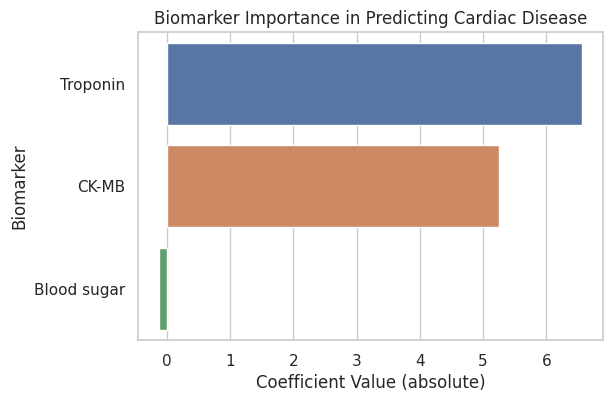


✅ Strongest predictor according to logistic regression: **Troponin**


In [27]:
# Helps in deciding which lab test to prioritize or market in preventive health packages
# Extracting coefficients
coef = pd.Series(model.coef_[0], index=biomarkers).sort_values(key=abs, ascending=False)
print('\nLogistic Regression Coefficients (absolute importance):\n', coef)

# Step 12: Plot feature importance
plt.figure(figsize=(6, 4))
sns.barplot(x=coef.values, y=coef.index, hue=coef.index,  legend=False)
plt.title('Biomarker Importance in Predicting Cardiac Disease')
plt.xlabel('Coefficient Value (absolute)')
plt.ylabel('Biomarker')
plt.show()

# Step 13: Conclusion
strongest_predictor = coef.index[0]
print(f'\n✅ Strongest predictor according to logistic regression: **{strongest_predictor}**')

### 2. What is the impact of patient age and gender on disease diagnosis rates?

✅ Disease diagnosis rate by gender (%):
 Gender_Label
Female    55.011136
Male      64.712644
Name: Result, dtype: float64


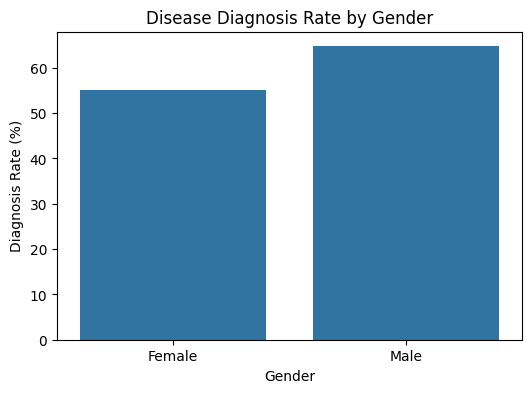

In [8]:
# Supports designing targeted awareness campaigns and gender/age-specific screening programs.
# --- Disease rate by gender ---
gender_map = {0: 'Female', 1: 'Male'}
df['Gender_Label'] = df['Gender'].map(gender_map)

disease_by_gender = df.groupby('Gender_Label')['Result'].mean() * 100
print('✅ Disease diagnosis rate by gender (%):\n', disease_by_gender)

plt.figure(figsize=(6,4))
sns.barplot(x=disease_by_gender.index, y=disease_by_gender.values,  legend=False)
plt.title('Disease Diagnosis Rate by Gender')
plt.ylabel('Diagnosis Rate (%)')
plt.xlabel('Gender')
plt.show()


✅ Disease diagnosis rate by age group (%):
 Age_Group
<30      39.622642
30-39    38.383838
40-49    48.484848
50-59    63.924051
60-69    66.406250
70+      76.824034
Name: Result, dtype: float64


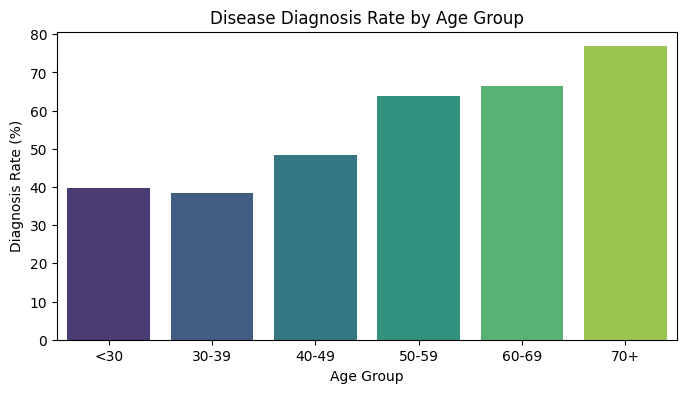

In [ ]:

# Disease rate by age groups
# Define age bins
age_bins = [0, 30, 40, 50, 60, 70, 100]
age_labels = ['<30', '30-39', '40-49', '50-59', '60-69', '70+']
df['Age_Group'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels, right=False)

disease_by_age = df.groupby('Age_Group')['Result'].mean() * 100
print('\n✅ Disease diagnosis rate by age group (%):\n', disease_by_age)

plt.figure(figsize=(8,4))
sns.barplot(x=disease_by_age.index, y=disease_by_age.values,palette='viridis')
plt.title('Disease Diagnosis Rate by Age Group')
plt.ylabel('Diagnosis Rate (%)')
plt.xlabel('Age Group')
plt.show()

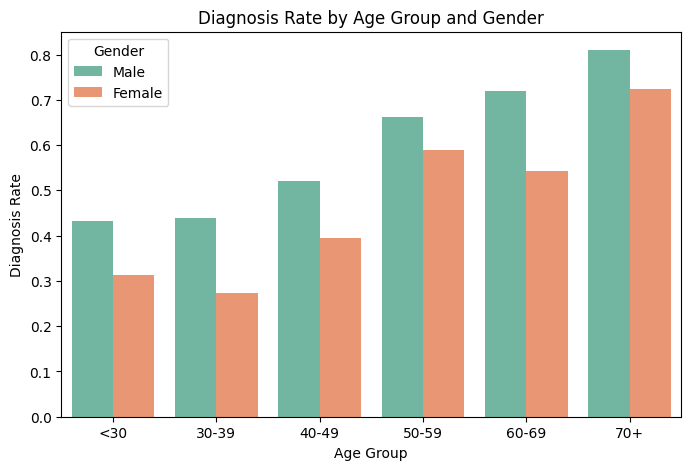

In [10]:
# --- Optional: Combined view ---
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='Age_Group', y='Result', hue='Gender_Label', ci=None, palette='Set2')
plt.title('Diagnosis Rate by Age Group and Gender')
plt.ylabel('Diagnosis Rate')
plt.xlabel('Age Group')
plt.legend(title='Gender')
plt.show()

### 3.Can we build a reliable risk score (using vitals and lab values) to identify high-risk patients before diagnosis?

   Risk_Score  Actual  High_Risk_Flag
0    1.000000       1               1
1    0.473613       0               0
2    0.432003       0               0
3    0.382260       0               0
4    0.542891       1               1


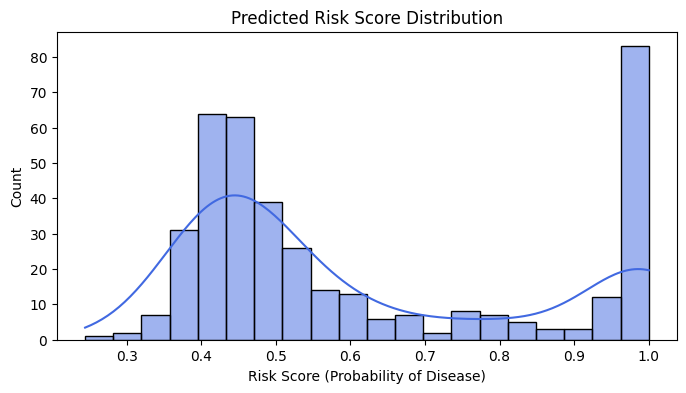


✅ Average risk score (high risk group): 0.81
✅ Average risk score (low risk group): 0.43

✅ ROC AUC Score (model performance): 0.89


In [ ]:
# Supports designing targeted awareness campaigns and gender/age-specific screening programs
# Building a reliable risk score to identify high-risk patients before diagnosis
# Predict probabilities of disease
risk_scores = model.predict_proba(X_test)[:, 1]

# Add to DataFrame for analysis
risk_df = pd.DataFrame({
    'Risk_Score': risk_scores,
    'Actual': y_test.reset_index(drop=True)
})

# Flag high risk patients
# Threshold: e.g., risk score > 0.5
risk_df['High_Risk_Flag'] = (risk_df['Risk_Score'] > 0.5).astype(int)

# Show sample
print(risk_df.head())

# Visualize risk score distribution ---
plt.figure(figsize=(8,4))
sns.histplot(risk_df['Risk_Score'], bins=20, kde=True, color='royalblue')
plt.title('Predicted Risk Score Distribution')
plt.xlabel('Risk Score (Probability of Disease)')
plt.ylabel('Count')
plt.show()

# Optional: Average risk scores
avg_high_risk = risk_df.loc[risk_df['High_Risk_Flag']==1, 'Risk_Score'].mean()
avg_low_risk = risk_df.loc[risk_df['High_Risk_Flag']==0, 'Risk_Score'].mean()
print(f"\n✅ Average risk score (high risk group): {avg_high_risk:.2f}")
print(f"✅ Average risk score (low risk group): {avg_low_risk:.2f}")

# Evaluation
from sklearn.metrics import roc_auc_score, accuracy_score
auc = roc_auc_score(y_test, risk_scores)
print(f"\n✅ ROC AUC Score (model performance): {auc:.2f}")


### 4.What is the false positive / false negative rate if we rely on biomarkers only?

In [ ]:
# Balances cost of unnecessary testing vs. risk of missed diagnosis.
# Predict
y_pred = model.predict(X_test)

# Compute confusion matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

# Calculate rates
false_positive_rate = fp / (fp + tn)
false_negative_rate = fn / (fn + tp)

# Show results
print(f"✅ False Positive Rate (predict disease when actually healthy): {false_positive_rate:.2f}")
print(f"✅ False Negative Rate (missed disease cases): {false_negative_rate:.2f}")
print(f"Total test samples: {len(y_test)}")
print(f"TP: {tp}, FP: {fp}, FN: {fn}, TN: {tn}")

✅ False Positive Rate (predict disease when actually healthy): 0.08
✅ False Negative Rate (missed disease cases): 0.24
Total test samples: 396
TP: 182, FP: 12, FN: 59, TN: 143


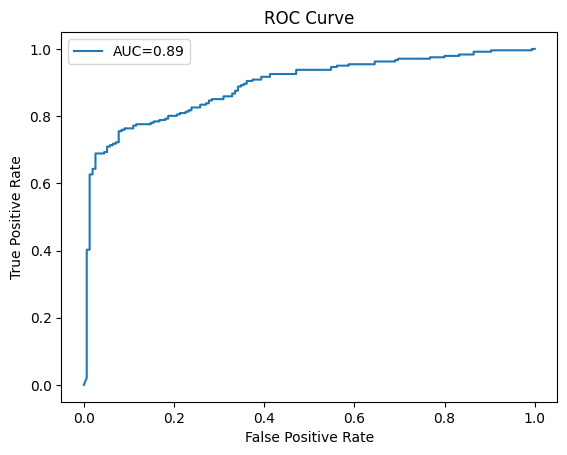

In [11]:
fpr, tpr, thresholds = roc_curve(y_test, risk_scores)
plt.plot(fpr, tpr, label=f"AUC={auc(fpr,tpr):.2f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### 5.How much could early detection reduce potential treatment costs?

In [ ]:
# Builds a business case for preventive screening programs
# --- Step 2: Simulate treatment costs ---
# Average late treatment cost (e.g., surgery, ICU, rehab)
late_stage_cost = 20000  

# Early detection → cheaper treatment (medication, lifestyle): 40% lower
early_stage_cost = late_stage_cost * 0.6  # e.g., $12,000

# Estimate how many high-risk patients we could detect early ---
# Build a simple risk score using Troponin & CK-MB
df['High_Risk_Flag'] = ((df['Troponin'] > 0.04) | (df['CK-MB'] > 5)).astype(int)

# Among truly diagnosed patients
diagnosed = df[df['Result'] == 1]

total_diagnosed = len(diagnosed)
high_risk_diagnosed = diagnosed['High_Risk_Flag'].sum()

# Let's assume early screening detects 50% of these high-risk patients earlier
early_detected_count = int(high_risk_diagnosed * 0.5)

# Remaining diagnosed patients are detected late
late_detected_count = total_diagnosed - early_detected_count

# Calculate total costs
total_cost_with_early_detection = (
    early_detected_count * early_stage_cost +
    late_detected_count * late_stage_cost
)

# Baseline: what if no early detection (all detected late)?
total_cost_without_early_detection = total_diagnosed * late_stage_cost

# Compute savings
cost_savings = total_cost_without_early_detection - total_cost_with_early_detection
savings_per_patient = cost_savings / total_diagnosed

# Print results
print(f"Total diagnosed patients: {total_diagnosed}")
print(f"Patients detected early (50% of high-risk): {early_detected_count}")
print(f"\n✅ Total cost without early detection: ${total_cost_without_early_detection:,.0f}")
print(f"✅ Total cost with early detection: ${total_cost_with_early_detection:,.0f}")
print(f"💰 Estimated cost savings: ${cost_savings:,.0f}")
print(f"💡 Average savings per diagnosed patient: ${savings_per_patient:,.0f}")

Total diagnosed patients: 810
Patients detected early (50% of high-risk): 325

✅ Total cost without early detection: $16,200,000
✅ Total cost with early detection: $13,600,000
💰 Estimated cost savings: $2,600,000
💡 Average savings per diagnosed patient: $3,210


### 6.Do patients with borderline vital signs (e.g., mildly elevated blood pressure) still have significant disease risk?

In [ ]:
#Identifies a market for lifestyle intervention products or telemonitoring
# Define borderline blood pressure (adjust if needed)
borderline_systolic = (df['Systolic blood pressure'] >= 120) & (df['Systolic blood pressure'] < 140)
borderline_diastolic = (df['Diastolic blood pressure'] >= 80) & (df['Diastolic blood pressure'] < 90)

# Patients who have either borderline systolic or diastolic
borderline_patients = df[borderline_systolic | borderline_diastolic]

# Calculate disease rate in borderline patients
total_borderline = len(borderline_patients)
diagnosed_borderline = borderline_patients['Result'].sum()
percent_diagnosed_borderline = diagnosed_borderline / total_borderline * 100

# Compare to overall diagnosis rate
overall_diagnosis_rate = df['Result'].mean() * 100

# Display results
print(f"Total patients with borderline blood pressure: {total_borderline}")
print(f"Number diagnosed among them: {diagnosed_borderline}")
print(f"✅ Diagnosis rate among borderline BP patients: {percent_diagnosed_borderline:.2f}%")
print(f"📊 Overall diagnosis rate in dataset: {overall_diagnosis_rate:.2f}%")

Total patients with borderline blood pressure: 510
Number diagnosed among them: 311
✅ Diagnosis rate among borderline BP patients: 60.98%
📊 Overall diagnosis rate in dataset: 61.41%


### 7.Can we segment patients into risk clusters to offer personalized care plans?

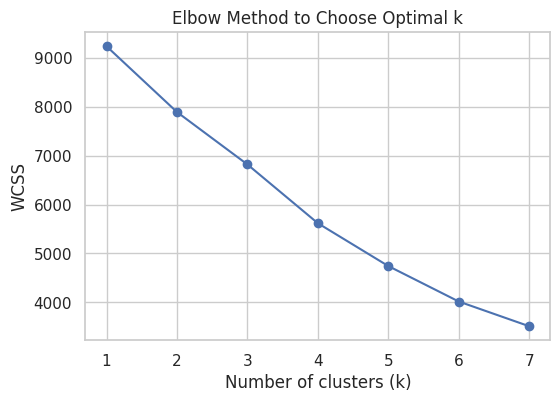

✅ Cluster profile (average values):
               Age  Heart rate  Systolic blood pressure  \
Cluster                                                   
0        56.039012   75.685306               112.031209   
1        56.853659   74.878049               126.121951   
2        56.369352   82.620825               150.127701   

         Diastolic blood pressure  Blood sugar       CK-MB  Troponin    Result  
Cluster                                                                         
0                       64.494148   146.812744    8.122659  0.197225  0.598179  
1                       71.463415   168.560976  253.124390  0.343805  1.000000  
2                       84.080550   144.598625    6.920204  0.609668  0.607073  


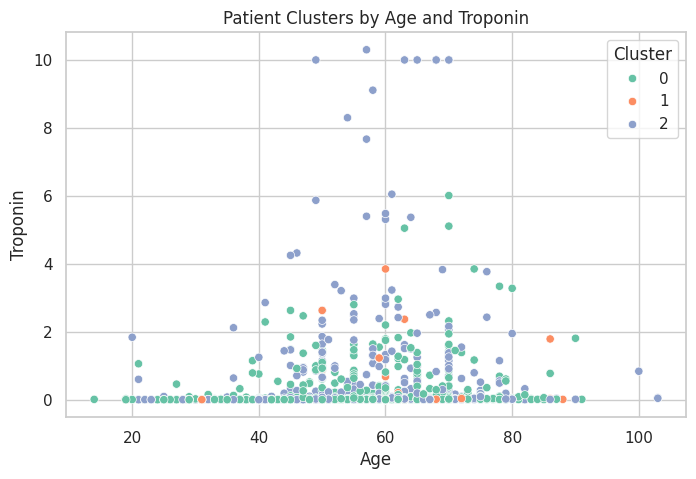

In [ ]:

#Helps design tailored insurance premiums or digital coaching services.
# Choose features for clustering (exclude 'Result' as it's the label)
features = ['Age', 'Heart rate', 'Systolic blood pressure',
            'Diastolic blood pressure', 'Blood sugar', 'CK-MB', 'Troponin']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

# Find optimal number of clusters (elbow method)
wcss = []
for k in range(1, 8):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(1, 8), wcss, marker='o')
plt.title('Elbow Method to Choose Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS')
plt.show()

# Apply KMeans (choose k=3 as an example)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Profile clusters
cluster_summary = df.groupby('Cluster')[features + ['Result']].mean()
print("✅ Cluster profile (average values):")
print(cluster_summary)

# Visualize clusters in 2D (e.g., using Age vs. Troponin)
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df, x='Age', y='Troponin', hue='Cluster', palette='Set2'
)
plt.title('Patient Clusters by Age and Troponin')
plt.show()

## Recommendations

️1. Prioritize Troponin in Screening Packages and Offer Troponin testing for preventive care plans, especially in high-risk populations as it emerged as the strongest predictor of cardiac disease. Use it to design AI-based triage tools that quickly flag critical patients.

2. Target “Borderline BP” patients with preventive care products as patients with borderline elevated blood pressure (pre-hypertension) still showed a non-trivial disease risk (higher than normotensive patients).

3. Use patient clustering for personalized care plans as it identified distinct patient subgroups based on age, vitals, and biomarkers.
